In [4]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

AI Labeling

In [5]:
def get_ai_labels(model_name, file_path):
    df = pd.read_csv(file_path, index_col=False)
    df['Image'] = df['Image'].str.replace('.PNG', '_' + model_name, case=False)
    df['Image'] = df['Image'].str.replace('.JPG', '_' + model_name, case=False)
    return df

ai_dalle = get_ai_labels('dalle', "AI labeling/gender_labels_ChatGPT_faces.csv")
ai_midjourney = get_ai_labels('midjourney', "AI labeling/gender_labels_Midjourney_faces.csv")
ai_stable_diffusion = get_ai_labels('stable_diffusion', "AI labeling/gender_labels_Stable Diffusion_faces.csv")

ai_labels = pd.concat([ai_dalle, ai_midjourney, ai_stable_diffusion], axis=0)
ai_labels = ai_labels.reset_index(drop=True)

ai_labels.rename(columns={"Gender": "ai_label"}, inplace=True)
ai_labels.rename(columns={"Confidence": "ai_confidence"}, inplace=True)

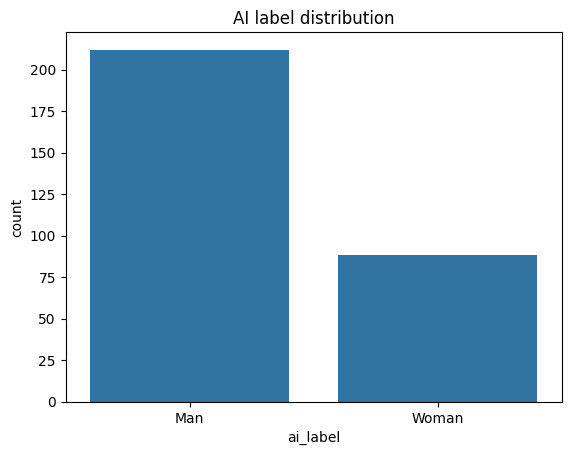

In [6]:
sns.countplot(x="ai_label", data=ai_labels)
plt.title("AI label distribution")
plt.show()

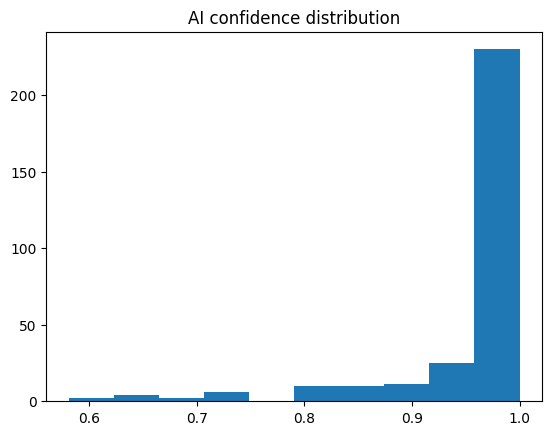

In [7]:
plt.hist(ai_labels['ai_confidence'], bins=10)
plt.title("AI confidence distribution")
plt.show()

Human Labeling

In [8]:
google_form = pd.read_csv("Human Labeling/google_form_responses.csv", index_col=False)

google_form = google_form.drop(columns=["What visual cues did you use to determine the person’s gender presentation?\n(e.g., clothing, hairstyle, body language)"])
google_form = google_form.drop(columns=["Email Address", "What gender do you identify yourself with?"])

google_form = google_form.T

google_form = google_form.reset_index(drop=True)
google_form = google_form.drop(index=0)
google_form = google_form.reset_index(drop=True)
total_response = google_form.shape[1]

google_form["human_label"] = google_form.mode(axis=1)[0]
google_form["mode_count"] = google_form.apply(lambda row: (row == row["human_label"]).sum(), axis=1) - 1
google_form["human_confidence"] = google_form["mode_count"] / total_response

professions_models = pd.read_csv("Human Labeling/google_form_professions.csv", index_col=False)
professions_models['Image'] = professions_models['profession'].astype(str) + professions_models['id'].astype(str) + '_' + professions_models['model'].astype(str)

human_labels = pd.concat([professions_models, google_form[["human_label", "human_confidence"]]], axis=1)
human_labels = human_labels.drop(columns=["id"])

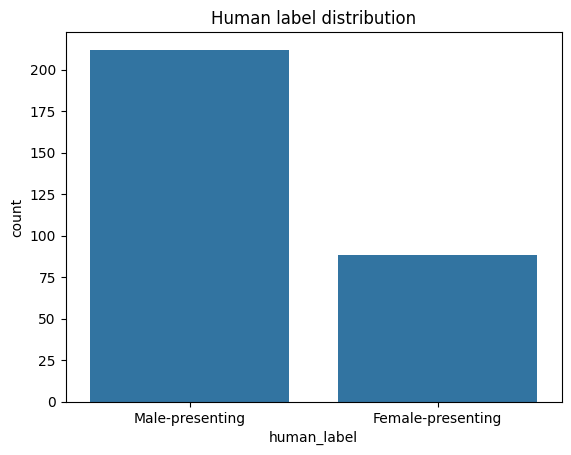

In [9]:
sns.countplot(x="human_label", data=human_labels)
plt.title("Human label distribution")
plt.show()

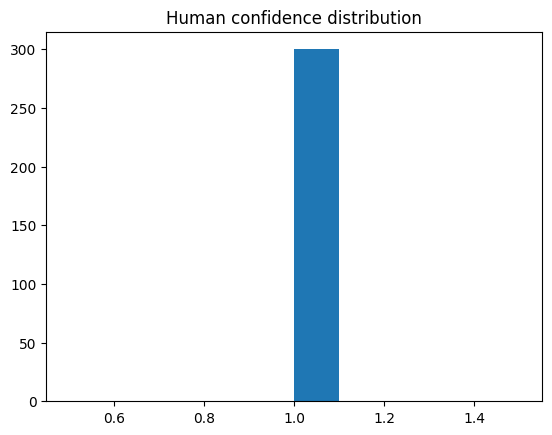

In [10]:
plt.hist(human_labels['human_confidence'], bins=10)
plt.title("Human confidence distribution")
plt.show()

Combined Labels

In [11]:
comparison_df = ai_labels.merge(human_labels, on="Image", how="inner")

comparison_df['ai_binary'] = comparison_df['ai_label'].map({
    "Man": 0,
    "Woman": 1,
    "Humans only, please": 2
})

comparison_df['human_binary'] = comparison_df['human_label'].map({
    "Male-presenting": 0,
    "Female-presenting": 1,
    "Androgynous / Ambiguous": 2,
    "Cannot tell": 2
})

from sklearn.metrics import cohen_kappa_score

kappa_ai = cohen_kappa_score(
    comparison_df['human_binary'],
    comparison_df['ai_binary']
)

print("Cohen's Kappa (Human-AI):", kappa_ai)


Cohen's Kappa (Human-AI): 1.0


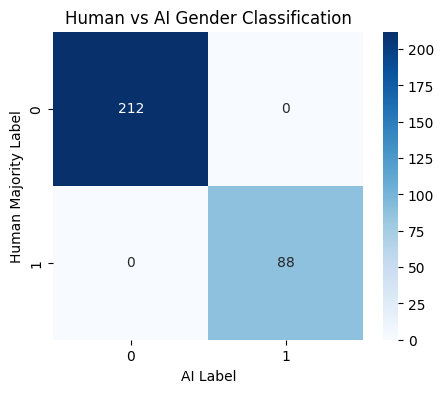

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    comparison_df['human_binary'],
    comparison_df['ai_binary']
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("AI Label")
plt.ylabel("Human Majority Label")
plt.title("Human vs AI Gender Classification")

plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_14584\3779570335.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  model_agreement = comparison_df.groupby("model").apply(


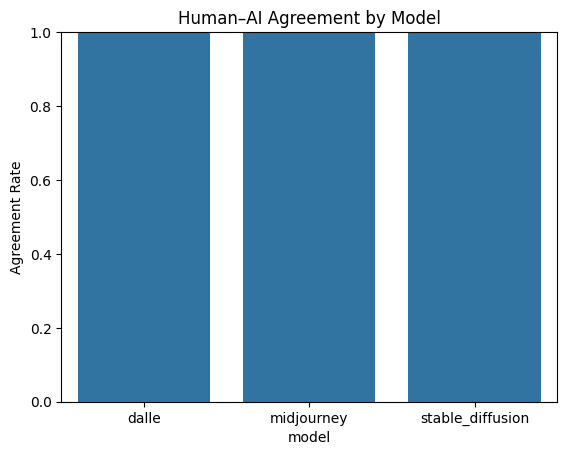

In [13]:
model_agreement = comparison_df.groupby("model").apply(
    lambda x: (x["human_binary"] == x["ai_binary"]).mean()
).reset_index(name="agreement_rate")

sns.barplot(
    data=model_agreement,
    x="model",
    y="agreement_rate"
)

plt.ylim(0,1)
plt.title("Human–AI Agreement by Model")
plt.ylabel("Agreement Rate")
plt.show()


In [14]:
human_labels.set_index("Image", inplace=True)
ai_labels.set_index("Image", inplace=True)

In [15]:
final_labels = ai_labels.merge(human_labels, on="Image", how="inner")

final_labels['label'] = None  # create empty column

final_labels.loc[(final_labels['ai_label'] == 'Man') & (final_labels['human_label'] == 'Male-presenting'), 'label'] = 0
final_labels.loc[(final_labels['ai_label'] == 'Woman') & (final_labels['human_label'] == 'Female-presenting'), 'label'] = 1

final_labels['confidence'] = (final_labels['ai_confidence']+final_labels['human_confidence'])/2
final_labels.loc[final_labels['confidence'] <= 0.85, 'label'] = None

final_labels = final_labels[final_labels['label'].notna()]

final_labels = final_labels.drop(columns=["ai_label", "ai_confidence", "human_label", "human_confidence"])

In [16]:
final_labels.to_csv("final_labels.csv", index=True)